In [1]:
# Binance Futures Bot — Recorrido guiado (paquete refactorizado)
# --------------------------------------------------------------
# Este archivo está dividido en celdas con "# %%" para que VS Code lo trate como Notebook.
# Flujo:
# 1) Cargar .env y Config
# 2) Cliente y llamadas reales (exchangeInfo, ticker/24hr)
# 3) Universo por volumen
# 4) OHLCV, ATR%, niveles 3 días y gráfico
# 5) Sizing (2.5% margen)
# 6) Previsualización de órdenes (sin enviar)
# 7) run_loop_once en DRY_RUN
#
# IMPORTANTE: Mantén DRY_RUN=true en tu .env mientras exploras.
# Activa tu virtualenv antes de correr.
# --------------------------------------------------------------


In [2]:
# (Opcional) Instalar dependencias si faltan
# Ejecuta esto solo si las necesitas.
# !pip install -r requirements.txt


In [ ]:
# 1) Cargar .env y revisar banderas
import os
from dotenv import load_dotenv, dotenv_values

dotenv_path = ".env"

env_keys = dotenv_values(dotenv_path).keys()

# delete old values
for key in env_keys:
    os.environ.pop(key, None)

# load new values
load_dotenv(dotenv_path)

print("BINANCE_FAPI_BASE =", os.getenv("BINANCE_FAPI_BASE", "https://fapi.binance.com"))
print("DRY_RUN =", os.getenv("DRY_RUN", "true"))


BINANCE_FAPI_BASE = https://fapi.binance.com
DRY_RUN = true


In [2]:
# 2) Importar el paquete y crear objetos base
import pandas as pd
import matplotlib.pyplot as plt

from binbot import Config, BinanceFutures, run_loop_once
from binbot.state import BotState
from binbot.filters import load_symbol_filters, passes_listing_age, passes_volume
from binbot.runner import symbol_universe, get_equity_usdt
from binbot.indicators import build_ohlcv, atr_percent, three_day_levels
from binbot.strategy import decide_orders_for_symbol
from binbot.housekeeping import cancel_stale_orders
from binbot.timeutil import now_utc

cfg = Config()
client = BinanceFutures(cfg)
state = BotState.load(cfg.state_path)

print(cfg)


Config(base_url='https://fapi.binance.com', dry_run=True, default_leverage=10, scan_interval_sec=60, kline_interval='1h', days_lookback=3, margin_pct=0.025, max_active_slots=10, min_listing_age_days=7, min_24h_usdt_volume=10000000.0, min_atr_pct=0.5, near_level_pct=20.0, offset_from_level_pct=0.05, stop_buffer_pct=0.05, max_order_age_hours=1, order_cooldown_hours=24, range_exclude_recent_bars=4, universe_size=40, symbols_whitelist=(), tz_local=datetime.timezone(datetime.timedelta(days=-1, seconds=64800)), window_start_hm=(0, 0), window_end_hm=(23, 0), max_retries=4, base_backoff=0.5, jitter=0.4, pause_threshold_used_weight=1000, pause_seconds_when_near=3.0, per_symbol_delay_min=0.1, per_symbol_delay_max=0.25, state_path='state.json', verbose=True, symbol_log_limit=0)


In [4]:
# 3) Llamadas reales: exchangeInfo → filtros por símbolo
ex = client.exchange_info()
sym_filters = load_symbol_filters(ex)

rows = []
for s, meta in sym_filters.items():
    if s.endswith("USDT"):  # enfocarnos en USDT-M
        rows.append({
            "symbol": s,
            "onboard_ms": meta["onboard_ms"],
            "stepSize": meta["stepSize"],
            "minQty": meta["minQty"],
            "tickSize": meta["tickSize"],
        })
df_sym = pd.DataFrame(rows).sort_values("symbol").reset_index(drop=True)
df_sym.head(20)


,symbol,onboard_ms,stepSize,minQty,tickSize
0,0GUSDT,1758123900000,1.00,1.00,1.000000e-04
1,1000000BOBUSDT,1749112200000,1.00,1.00,1.000000e-05
2,1000000MOGUSDT,1730982600000,0.10,0.10,1.000000e-04
3,1000BONKUSDT,1700661600000,1.00,1.00,1.000000e-06
4,1000CATUSDT,1729513800000,1.00,1.00,1.000000e-06
5,1000CHEEMSUSDT,1732535100000,1.00,1.00,1.000000e-07
6,1000FLOKIUSDT,1683331200000,1.00,1.00,1.000000e-05
7,1000LUNCUSDT,1662620400000,1.00,1.00,1.000000e-05
8,1000PEPEUSDT,1683244800000,1.00,1.00,1.000000e-07
9,1000RATSUSDT,1702648800000,1.00,1.00,1.000000e-05


In [5]:
# 4) Llamadas reales: ticker/24hr → top por volumen
tickers = client.ticker_24h()
tdf = pd.DataFrame(tickers)

# Algunas versiones traen "contractType"; si no, filtramos por sufijo USDT
if "contractType" in tdf.columns:
    tdf = tdf[(tdf["symbol"].str.endswith("USDT")) & (tdf["contractType"] == "PERPETUAL")]
else:
    tdf = tdf[tdf["symbol"].str.endswith("USDT")]

tdf["quoteVolume"] = pd.to_numeric(tdf["quoteVolume"], errors="coerce")
tdf_top = tdf.sort_values("quoteVolume", ascending=False).head(20)[["symbol", "quoteVolume"]]
tdf_top.reset_index(drop=True)


,symbol,quoteVolume
0,ETHUSDT,1.681774e+10
1,BTCUSDT,1.315902e+10
2,SOLUSDT,5.351492e+09
3,ASTERUSDT,3.076721e+09
4,ALPACAUSDT,2.911352e+09
5,DOGEUSDT,2.100910e+09
6,XRPUSDT,1.831277e+09
7,AVNTUSDT,1.258524e+09
8,BNBUSDT,1.242684e+09
9,AVAXUSDT,9.613044e+08


In [6]:
# 5) Construir universo (por volumen o whitelist desde cfg)
universe = symbol_universe(client, cfg)
print("Tamaño universo:", len(universe))
universe[:20]


Tamaño universo: 40


['ETHUSDT',
 'BTCUSDT',
 'SOLUSDT',
 'ASTERUSDT',
 'ALPACAUSDT',
 'DOGEUSDT',
 'XRPUSDT',
 'AVNTUSDT',
 'BNBUSDT',
 'AVAXUSDT',
 'HEMIUSDT',
 'STBLUSDT',
 'PUMPUSDT',
 'HYPEUSDT',
 'INUSDT',
 '0GUSDT',
 'SUIUSDT',
 'BLESSUSDT',
 'BNXUSDT',
 'WLFIUSDT']

focus_symbol = ETHUSDT
Filas OHLCV: 74
ATR% (20): 0.9456
3-day High: 4230.06 3-day Low: 3961.0 Last: 4001.05


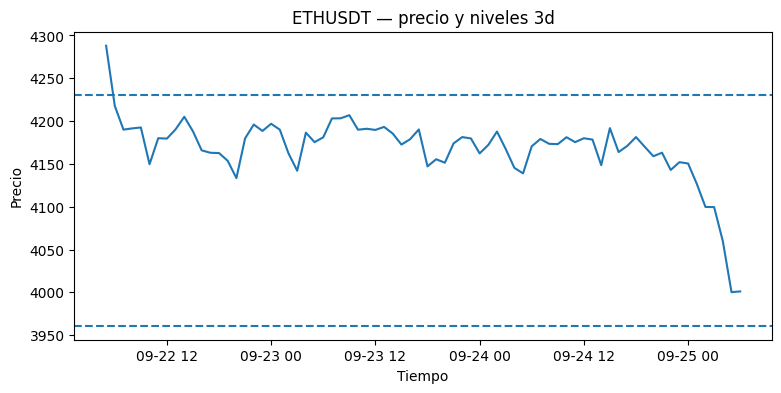

In [7]:
# 6) OHLCV de un símbolo foco + ATR% + niveles 3 días + gráfico
from datetime import timedelta

focus_symbol = universe[0] if universe else "BTCUSDT"
print("focus_symbol =", focus_symbol)

end = now_utc()
start = end - timedelta(days=cfg.days_lookback, hours=2)
rows = client.klines(
    focus_symbol,
    cfg.kline_interval,
    int(start.timestamp()*1000),
    int(end.timestamp()*1000)
)
df = build_ohlcv(rows)

print("Filas OHLCV:", len(df))

# bars_needed para 3 días (si usas 15m); si cambias el intervalo, ajusta la lógica.
if cfg.kline_interval == "15m":
    bars_needed = int((24 * 60) / 15 * cfg.days_lookback)
else:
    bars_needed = max(1, int(len(df) * 0.8))

hi, lo = three_day_levels(df, bars_needed=bars_needed)
atrp = atr_percent(df, period=20)
last = float(df["close"].iloc[-1])

print("ATR% (20):", round(atrp, 4))
print("3-day High:", hi, "3-day Low:", lo, "Last:", last)

plt.figure(figsize=(9, 4))
plt.plot(df["close_time"], df["close"])
plt.axhline(hi, linestyle="--")
plt.axhline(lo, linestyle="--")
plt.title(f"{focus_symbol} — precio y niveles 3d")
plt.xlabel("Tiempo")
plt.ylabel("Precio")
plt.show()


In [8]:
# 7) Sizing con 2.5% del equity como margen
equity = get_equity_usdt(client)
print("Equity USDT:", equity)

meta = sym_filters[focus_symbol]
step = meta["stepSize"]
min_qty = meta["minQty"]
tick = meta["tickSize"]

from binbot.sizing import compute_qty
qty = compute_qty(
    price=last,
    equity=equity,
    leverage=cfg.default_leverage,
    margin_pct=cfg.margin_pct,
    step=step,
    min_qty=min_qty
)
print("Qty estimada:", qty)


HTTPError: 401 Client Error: Unauthorized for url: https://fapi.binance.com/fapi/v2/account?timestamp=1758776490351&signature=8234a824c24f198b985dc83c556f5ca54e4b66f705c25efef4dacaaef96bd483

In [8]:
# 8) Previsualizar órdenes que pondría (sin enviar)
planned = decide_orders_for_symbol(
    client=client,
    symbol=focus_symbol,
    sym_filters=sym_filters,
    last_open_iso_by_symbol=state.last_open_iso_by_symbol,
    tdf=tdf,
    equity=equity,
    cfg=cfg
)

df_planned = pd.DataFrame([od.__dict__ for od in planned]) if planned else pd.DataFrame()
df_planned if not df_planned.empty else "No hay órdenes planeadas para el símbolo foco con los filtros actuales."


  - stats: ATR%=0.888 last=4039.690000 hi=4308.770000 lo=4000.880000
  - proximity: to_hi=6.245% (near), to_lo=0.970% (near)


,symbol,side,type,quantity,price,time_in_force,context
0,ETHUSDT,BUY,LIMIT,0.011,4002.88,GTC,long near low 4000.8800


In [9]:
# 9) Housekeeping: detectar/cancelar órdenes >24h (en DRY_RUN solo loguea)
cancel_stale_orders(client, cfg.max_order_age_hours, cfg.dry_run, log_fn=print)


DRYRUN cancel stale AWEUSDT #329601241 (age >= 1h)


In [9]:
# 10) Ejecutar run_loop_once (una pasada) en DRY_RUN
def logger(msg):
    print(msg)

run_loop_once(cfg, client, state, log_fn=logger)


DRYRUN cancel stale AWEUSDT #329601241 (age >= 1h)
Equity: 186.22 | Active: orders=1 positions=0
Universe (40): ETHUSDT, BTCUSDT, SOLUSDT, ASTERUSDT, ALPACAUSDT, DOGEUSDT, XRPUSDT, AVNTUSDT, BNBUSDT, AVAXUSDT, HEMIUSDT, STBLUSDT, PUMPUSDT, INUSDT, HYPEUSDT, 0GUSDT, SUIUSDT, BLESSUSDT, BNXUSDT, WLFIUSDT, ENAUSDT, 1000PEPEUSDT, LINKUSDT, ALPHAUSDT, XPLUSDT, ADAUSDT, LINEAUSDT, BARDUSDT, FLUIDUSDT, FARTCOINUSDT ...
[1/40] ETHUSDT → evaluating
  - stats: ATR%=0.888 last=4037.730000 hi=4308.770000 lo=4000.880000
  - proximity: to_hi=6.290% (near), to_lo=0.921% (near)
DRYRUN place: ETHUSDT | long near low 4000.8800 | qty=0.011 @ 4002.88
[2/40] BTCUSDT → evaluating
  - SKIP atr: 0.446 < 0.5
[3/40] SOLUSDT → evaluating
  - stats: ATR%=1.211 last=204.430000 hi=233.090000 lo=204.730000
  - SKIP band: last is below previous range [204.730000, 233.090000]
[4/40] ASTERUSDT → evaluating
  - SKIP listing age: onboard=1758283200000 (< 7d)
[5/40] ALPACAUSDT → evaluating
  - SKIP listing age: onboard=0 

In [ ]:
# 11) Envíos reales (PELIGRO)
# Para probar envíos reales, cambia DRY_RUN=false en tu .env, reinicia el kernel y vuelve a correr.
# print("dry_run =", cfg.dry_run)